# No Derivation, No Relation — iter-10 `$0` Re-analysis (Demo)

**Artifact:** `art_lwoQWfQWMQfc` — *iter-10 `$0` re-analysis: stronger-verifier rigor fix + 4 MINOR fixes + abstract FORK.*

This notebook is a **minimal, runnable demo** of the iter-10 **pure `$0`** re-analysis (no LLM, no
network — `numpy`/`scipy`/`json` only) behind the closure-certificate paper
*"No Derivation, No Relation."*

The full `eval.py` reads frozen per-query rows from three iter-8/iter-9 experiments
(**S1** located-in, **S2** verifier, **S3** booster) and runs a **reproduction / no-spend gate**
that recomputes *every* paper-facing literal from the rows and hard-asserts it matches the carried
metadata. This demo focuses on the most self-contained block — the **located-in (S1) re-analysis** —
and reproduces its core machinery on a curated ~100-row subset:

- **FACT-A** — the confident absent-relation *fabrication rate* (the robust diagnostic).
- **Caught-fraction** — what fraction of the raw reader's confident fabrications each method turns
  into abstentions. The **no-derivation certificate** is compared against 4 confidence signals
  (verbalized, P(True), self-consistency margin, semantic-entropy) + 2 query-side verifiers.
- **Natural confident-wrong rate** on the absent pool.
- **Doc-clustered paired bootstrap** of the certificate-minus-method caught gap (with 95% CI).

> The demo recomputes these on the subset, so the numbers are *illustrative*. The full-data
> published literals (n = 515 present / 450 sibling / 250 diffcomp) are shipped in
> `carried_reference` and shown **side-by-side** with the subset values.

## Setup

Install dependencies. The original `eval.py` uses `loguru` for logging (installed everywhere);
the scientific core (`numpy`, `scipy`, `matplotlib`) is pre-installed on Colab and pinned locally
to Colab's versions.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab; the original eval.py uses it. Install everywhere.
_pip('loguru==0.7.2')

# Core scientific packages: pre-installed on Colab (skip there); install locally at Colab's versions.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


### Imports — copied from `eval.py`'s import block + logging setup (+ matplotlib for the demo plot)

In [2]:
from __future__ import annotations

import json
import math
import sys
import resource
from collections import defaultdict
from pathlib import Path

import numpy as np
from scipy import stats as scipy_stats  # noqa: F401  (available for completeness)
from loguru import logger

import matplotlib.pyplot as plt  # (demo) for the final visualization

# ---- STEP 0: logging setup (verbatim from eval.py) ----
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
Path("logs").mkdir(exist_ok=True)
logger.add("logs/run.log", rotation="30 MB", level="DEBUG")

# Memory limit (these JSONs are tiny so this is ample headroom).
_RAM_BUDGET = 4 * 1024 ** 3
try:
    resource.setrlimit(resource.RLIMIT_AS, (_RAM_BUDGET * 3, _RAM_BUDGET * 3))
except (ValueError, OSError):
    pass

# $0 cost counter — there is NO LLM path; never incremented; asserted == 0 at the end.
COST_USD = 0.0
N_LLM_CALLS = 0
print("imports OK — pure $0 re-analysis (no LLM, no network)")

imports OK — pure $0 re-analysis (no LLM, no network)


### Data loading

The demo loads a curated subset of the iter-8 located-in per-query rows from GitHub, with a local
fallback so it runs both in Colab (after deployment) and locally (now).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-40a89b-no-derivation-no-relation-a-closure-cert/main/round-10/evaluation-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("loaded:", data["source"])
print("strata:", {k: len(v) for k, v in data["datasets"].items()})
print("carried_reference keys:", list(data["carried_reference"].keys()))

loaded: iter-8 located-in (S1) full_method_out.json — curated demo subset
strata: {'locatedin_present': 30, 'locatedin_absent_sibling': 60, 'locatedin_absent_diffcomponent': 10}
carried_reference keys: ['counts', 'FACT_A', 'caught_fraction_n450', 'natural_confident_wrong_sibling', 'gold_read_ceiling', 'verdict']


## Config

All tunable parameters live here. Defaults use the **whole curated subset** (only ~100 rows) and a
moderate bootstrap. The original `eval.py` uses `B = 10000`; the data is tiny so larger values still
run in well under a second.

In [5]:
# ---- CONFIG: tunable demo parameters (start MINIMAL, scale up) ----
# Rows to use from each located-in stratum (None = use all rows in the subset).
N_PRESENT = None    # present pool (anchors the certificate's coverage)
N_SIBLING = None    # same-component-sibling absent pool (carries the headline fabrications)
N_DIFF    = None    # different-component absent pool (near-zero-fabrication contrast)

# Doc-clustered paired bootstrap resamples. Matches the original eval.py (the data is tiny, so the
# full B runs in a fraction of a second). For a faster first pass set BOOTSTRAP_B = 2000.
BOOTSTRAP_B = 10000

# Constants copied verbatim from eval.py
ABSTAIN = {"ABSTAIN", "no-relation", "no_relation", "none", ""}
SIGNALS = ("verbalized", "sc_margin", "ptrue", "negent")
REPRO_SEED = 20260618   # the booster's own seed
EVAL_SEED  = 20260617   # used for any genuinely-NEW bootstrap statistic
print(f"config: N_PRESENT={N_PRESENT} N_SIBLING={N_SIBLING} N_DIFF={N_DIFF} BOOTSTRAP_B={BOOTSTRAP_B}")

config: N_PRESENT=None N_SIBLING=None N_DIFF=None BOOTSTRAP_B=10000


## Re-analysis primitives (verbatim from `eval.py`)

These small helpers define what it means for a prediction to *name* a relation, the rounding used
throughout, and the **matched-coverage threshold** — the rule that lets every confidence signal be
compared to the certificate at the *same* coverage (top `round(cov*N)` predictions by confidence).

In [6]:
def is_named(pred) -> bool:
    """A prediction NAMES a relation iff it is not an abstain/no-relation marker."""
    return (pred is not None) and (str(pred) not in ABSTAIN)


def _r(x, nd=4):
    if x is None:
        return None
    if isinstance(x, float) and (math.isnan(x) or math.isinf(x)):
        return None
    return round(float(x), nd)


def matched_coverage_mask(conf: np.ndarray, target_cov: float) -> np.ndarray:
    """Replicates stats.matched_coverage_mask EXACTLY: top ceil(round) cov*N by (-conf, idx)."""
    n = len(conf)
    k = int(round(target_cov * n))
    k = max(0, min(n, k))
    mask = np.zeros(n, dtype=bool)
    if k == 0:
        return mask
    order = sorted(range(n), key=lambda i: (-conf[i], i))
    for i in order[:k]:
        mask[i] = True
    return mask


def coverage_confidence(named: bool, conf: float) -> float:
    return float(conf) if named else -1.0

### Reproduction-gate accounting (`Gate`) — verbatim from `eval.py`

The full eval records **hard** checks (recompute-from-rows must match the carried literal exactly,
else HARD STOP) and **soft** cross-checks (Monte-Carlo CIs, warn-only). In this demo we run the
located-in literals as *soft* cross-checks: the subset is not the full pool, so we compare with a
loose tolerance instead of hard-asserting.

In [7]:
class Gate:
    def __init__(self):
        self.checks = []      # hard checks (mismatch => HARD STOP in the full eval)
        self.soft = []        # soft cross-checks (warn only)

    def hard(self, name, recomputed, carried, tol):
        ok = (recomputed is not None and carried is not None
              and abs(float(recomputed) - float(carried)) <= tol)
        self.checks.append({"name": name, "recomputed": _r(recomputed, 6),
                            "carried": _r(carried, 6), "tol": tol, "ok": bool(ok)})
        lvl = "DEBUG" if ok else "ERROR"
        logger.log(lvl, f"[HARD {'OK ' if ok else 'FAIL'}] {name}: recomputed={recomputed} carried={carried} tol={tol}")
        return ok

    def soft_check(self, name, recomputed, carried, tol, note=""):
        ok = (recomputed is not None and carried is not None
              and abs(float(recomputed) - float(carried)) <= tol)
        self.soft.append({"name": name, "recomputed": _r(recomputed, 6),
                          "carried": _r(carried, 6), "tol": tol, "ok": bool(ok), "note": note})
        logger.info(f"[SOFT {'OK ' if ok else 'LOOSE'}] {name}: recomputed={recomputed} carried={carried} tol={tol} {note}")
        return ok

    def all_ok(self):
        return all(c["ok"] for c in self.checks)

    def n_passed(self):
        return sum(1 for c in self.checks if c["ok"])

### `crux_caught` — the headline metric (verbatim from `eval.py`)

For the MIXED pool (present + absent of a regime) this computes, for the certificate and each
confidence signal at matched coverage, the **fraction of the raw reader's confident fabrications
that get caught** (turned into an abstention). Query-side verifiers (`predict_queryside_*`), when
present in the rows, are also scored.

In [8]:
def crux_caught(records, sigkey="metadata_conf_{}"):
    """Reproduce the located-in / Re-DocRED crux fraction-caught for the 4 dispersion signals,
    the certificate, and (if present in the rows) the 2 query-side gates.  `records` = the MIXED
    pool (present + absent of the regime).  Certificate-matched global threshold tuned to the
    certificate's MIXED coverage (matches the source method.py)."""
    N = len(records)
    cert_named = np.array([is_named(r.get("predict_certificate")) for r in records], bool)
    raw_named = np.array([bool(r.get("metadata_raw_named")) for r in records], bool)
    is_abs = np.array([bool(r.get("metadata_is_absent")) for r in records], bool)
    cert_cov_mixed = float(cert_named.mean()) if N else float("nan")

    absent_idx = np.where(is_abs)[0]
    halluc_idx = np.array([i for i in absent_idx if raw_named[i]], int)
    n_h = len(halluc_idx)

    out = {"n": N, "n_absent": int(is_abs.sum()), "n_raw_confident_wrong": n_h,
           "certificate_coverage_mixed": _r(cert_cov_mixed), "per_method": {}}

    cert_caught = float(np.mean([0.0 if cert_named[i] else 1.0 for i in halluc_idx])) if n_h else float("nan")
    out["per_method"]["certificate"] = {"fraction_caught": _r(cert_caught),
                                        "fraction_surviving": _r(1.0 - cert_caught) if cert_caught == cert_caught else None}

    for s in SIGNALS:
        m = f"ct_{s}"
        ct_named = raw_named  # ct commits raw's answer; named == raw_named
        sig_all = np.array([float(r.get(sigkey.format(s), 0.0) or 0.0) for r in records], float)
        conf_mixed = np.where(ct_named, sig_all, -1.0)
        tau_global = float("nan")
        if N and cert_cov_mixed == cert_cov_mixed:
            mask = matched_coverage_mask(conf_mixed, cert_cov_mixed)
            covered = sorted([conf_mixed[i] for i in range(N) if mask[i] and conf_mixed[i] >= 0.0])
            tau_global = covered[0] if covered else float("nan")
        vals = np.array([sig_all[i] for i in halluc_idx], float) if n_h else np.array([])
        frac_surv = float(np.mean(vals >= tau_global)) if (n_h and tau_global == tau_global) else float("nan")
        out["per_method"][m] = {"fraction_surviving": _r(frac_surv),
                                "fraction_caught": _r(1.0 - frac_surv) if frac_surv == frac_surv else None,
                                "tau_global": _r(tau_global)}
    for qs in ("queryside_verifier", "queryside_selfverify"):
        key = f"predict_{qs}"
        if any(key in r for r in records):
            surv = float(np.mean([1.0 if is_named(records[i].get(key)) else 0.0 for i in halluc_idx])) if n_h else float("nan")
            out["per_method"][qs] = {"fraction_surviving": _r(surv),
                                     "fraction_caught": _r(1.0 - surv) if surv == surv else None}
    return out

### `natural_cw_rate` + doc-clustered bootstrap (verbatim from `eval.py`)

`natural_cw_rate` is the raw confident-wrong rate on an absent pool. The bootstrap resamples
**documents** (not rows) with replacement to get a doc-clustered 95% CI on the
*certificate-minus-method* caught gap — the statistic that establishes the certificate's one-sided
catching advantage.

In [9]:
def natural_cw_rate(records, predkey):
    """Confident-wrong rate on an ABSENT pool: fraction of rows where the method NAMES a relation
    (any named answer on an absent pair is wrong)."""
    if not records:
        return float("nan")
    return float(np.mean([1.0 if is_named(r.get(predkey)) else 0.0 for r in records]))


def doc_clustered_caught_gap_bootstrap(cert_caught_vec, comp_caught_vec, doc_ids, B=10000, seed=EVAL_SEED):
    """NEW statistic: doc-clustered paired bootstrap of (cert_caught - comp_caught) over the
    fabrication set.  Resample DOCUMENTS with replacement.  Returns point, CI95, one-sided p."""
    cert_caught_vec = np.asarray(cert_caught_vec, float)
    comp_caught_vec = np.asarray(comp_caught_vec, float)
    point = float(cert_caught_vec.mean() - comp_caught_vec.mean())
    by_doc = defaultdict(list)
    for i, d in enumerate(doc_ids):
        by_doc[d].append(i)
    docs = list(by_doc)
    nd = len(docs)
    rng = np.random.default_rng(seed)
    gaps = []
    for _ in range(B):
        pick = rng.integers(0, nd, nd)
        idx = np.concatenate([by_doc[docs[i]] for i in pick]) if nd else np.array([], int)
        if len(idx) == 0:
            continue
        gaps.append(float(cert_caught_vec[idx].mean() - comp_caught_vec[idx].mean()))
    gaps = np.array(gaps, float)
    lo, hi = np.quantile(gaps, [0.025, 0.975])
    p_one = max(float(np.mean(gaps <= 0.0)), 1.0 / (len(gaps) + 1))
    return {"gap": _r(point), "ci95": [_r(lo), _r(hi)], "p_one_sided": _r(p_one),
            "ci_excludes_0": bool(lo > 0.0), "n_boot": int(len(gaps))}

## Located-in groups & FACT-A

Slice the three located-in strata from the loaded subset and build the **present + sibling** mixed
pool. **FACT-A** is the confident absent-relation fabrication rate — the fraction of absent pairs
the raw reader confidently NAMED a (wrong) relation for.

In [10]:
groups = data["datasets"]
ref = data["carried_reference"]

li_present = groups["locatedin_present"][:N_PRESENT] if N_PRESENT else groups["locatedin_present"]
li_sib     = groups["locatedin_absent_sibling"][:N_SIBLING] if N_SIBLING else groups["locatedin_absent_sibling"]
li_diff    = groups["locatedin_absent_diffcomponent"][:N_DIFF] if N_DIFF else groups["locatedin_absent_diffcomponent"]
li_sib_mixed = li_present + li_sib   # present + sibling-absent MIXED pool

logger.info(f"located-in subset: present={len(li_present)} sibling={len(li_sib)} diff={len(li_diff)}")

# FACT-A: confident absent-relation fabrication rate
factA_sib  = float(np.mean([1.0 if r["metadata_raw_named"] else 0.0 for r in li_sib]))
factA_diff = float(np.mean([1.0 if r["metadata_raw_named"] else 0.0 for r in li_diff]))
n_hall_sib = int(np.sum([1 for r in li_sib if r["metadata_raw_named"]]))
print(f"FACT-A sibling  (subset) = {factA_sib:.4f}   | carried full-data = {ref['FACT_A']['same_component_sibling']}")
print(f"FACT-A diffcomp (subset) = {factA_diff:.4f}   | carried full-data = {ref['FACT_A']['different_component']}")
print(f"# confident fabrications in sibling subset = {n_hall_sib}")

23:43:45|INFO   |located-in subset: present=30 sibling=60 diff=10


FACT-A sibling  (subset) = 0.2500   | carried full-data = 0.3
FACT-A diffcomp (subset) = 0.1000   | carried full-data = 0.06
# confident fabrications in sibling subset = 15


## BLOCK 0 (demo) — recompute-from-rows vs carried literals

The reproduction gate's spirit: recompute every paper-facing number directly from the per-query
rows and compare to the carried literal. Here we recompute the **caught-fractions** (via
`crux_caught`) and the **natural confident-wrong rates** (via `natural_cw_rate`) and cross-check
them against the carried full-data values as *soft* checks (loose tolerance, since the subset is
much smaller than the n=450 pool).

In [11]:
GATE = Gate()

# recompute caught fractions from the rows
li_crux = crux_caught(li_sib_mixed)
cm = li_crux["per_method"]
print(f"# raw confident-wrong (fabrications) in mixed pool = {li_crux['n_raw_confident_wrong']}")
print(f"certificate coverage on mixed pool = {li_crux['certificate_coverage_mixed']}\n")

ref_caught = ref["caught_fraction_n450"]
for key, carried in ref_caught.items():
    GATE.soft_check(f"caught.{key}", cm[key]["fraction_caught"], carried, tol=0.20, note="subset vs full-data literal")

# natural confident-wrong on the sibling-absent pool
li_natcw = {
    "certificate":        natural_cw_rate(li_sib, "predict_certificate"),
    "ct_verbalized":      natural_cw_rate(li_sib, "predict_conf_thresh_verbalized"),
    "queryside_verifier": natural_cw_rate(li_sib, "predict_queryside_verifier"),
}
ref_ncw = ref["natural_confident_wrong_sibling"]
for key, carried in ref_ncw.items():
    GATE.soft_check(f"natural_cw.{key}", li_natcw[key], carried, tol=0.20)

print(f"\nsoft cross-checks within tol: {sum(1 for s in GATE.soft if s['ok'])}/{len(GATE.soft)}")

# raw confident-wrong (fabrications) in mixed pool = 15
certificate coverage on mixed pool = 0.0778

23:43:45|INFO   |[SOFT OK ] caught.certificate: recomputed=0.7333 carried=0.7852 tol=0.2 subset vs full-data literal


23:43:45|INFO   |[SOFT OK ] caught.ct_verbalized: recomputed=0.2667 carried=0.4 tol=0.2 subset vs full-data literal


23:43:45|INFO   |[SOFT OK ] caught.ct_ptrue: recomputed=0.1333 carried=0.3037 tol=0.2 subset vs full-data literal


23:43:45|INFO   |[SOFT OK ] caught.ct_sc_margin: recomputed=0.0667 carried=0.0667 tol=0.2 subset vs full-data literal


23:43:45|INFO   |[SOFT OK ] caught.ct_negent: recomputed=0.0667 carried=0.0667 tol=0.2 subset vs full-data literal


...

23:43:45|INFO   |[SOFT OK ] caught.queryside_selfverify: recomputed=0.3333 carried=0.4593 tol=0.2 subset vs full-data literal


23:43:45|INFO   |[SOFT OK ] natural_cw.certificate: recomputed=0.08333333333333333 carried=0.0733 tol=0.2 


23:43:45|INFO   |[SOFT OK ] natural_cw.ct_verbalized: recomputed=0.25 carried=0.3 tol=0.2 


23:43:45|INFO   |[SOFT OK ] natural_cw.queryside_verifier: recomputed=0.18333333333333332 carried=0.2178 tol=0.2 



soft cross-checks within tol: 10/10


## BLOCK 1 (demo) — corrected caught-fraction leaderboard with doc-clustered gaps

For each method we bootstrap the **certificate-minus-method caught gap** over documents and report
its 95% CI. In the full eval all six gaps exclude 0 (the certificate strictly out-catches every
confidence signal and both query-side verifiers). On the small subset the point gaps reproduce the
ordering; CIs are wider because there are far fewer fabrications/documents.

In [12]:
fab_li = [r for r in li_sib if r.get("metadata_raw_named")]   # the fabrications
fab_doc_ids = [r["metadata_doc_id"] for r in fab_li]
cert_caught_vec = np.array([1.0 if not is_named(r["predict_certificate"]) else 0.0 for r in fab_li], float)
tau = {s: li_crux["per_method"][f"ct_{s}"]["tau_global"] for s in SIGNALS}

leaderboard = {"certificate": {"fraction_caught": _r(cm["certificate"]["fraction_caught"])}}
gaps = {}
for s in SIGNALS:
    m = f"ct_{s}"
    comp_caught_vec = np.array([1.0 if (float(r.get(f"metadata_conf_{s}", 0.0) or 0.0) < tau[s]) else 0.0
                                for r in fab_li], float)
    gap = doc_clustered_caught_gap_bootstrap(cert_caught_vec, comp_caught_vec, fab_doc_ids, B=BOOTSTRAP_B, seed=EVAL_SEED)
    leaderboard[m] = {"fraction_caught": _r(cm[m]["fraction_caught"]), "cert_minus_method_caught_gap": gap}
    gaps[m] = gap
for qs in ("queryside_verifier", "queryside_selfverify"):
    comp_caught_vec = np.array([1.0 if not is_named(r[f"predict_{qs}"]) else 0.0 for r in fab_li], float)
    gap = doc_clustered_caught_gap_bootstrap(cert_caught_vec, comp_caught_vec, fab_doc_ids, B=BOOTSTRAP_B, seed=EVAL_SEED)
    leaderboard[qs] = {"fraction_caught": _r(cm[qs]["fraction_caught"]), "cert_minus_method_caught_gap": gap}
    gaps[qs] = gap

gaps_excluding_0 = [m for m, g in gaps.items() if g["ci_excludes_0"]]
print(f"# fabrications used = {len(fab_li)}; methods whose cert-minus-method gap CI excludes 0 "
      f"(subset): {len(gaps_excluding_0)}/{len(gaps)}\n")
print(f"{'method':22s} {'caught':>7s}  {'gap':>7s}  {'95% CI':>18s}  excl0")
for m, g in gaps.items():
    print(f"{m:22s} {leaderboard[m]['fraction_caught']:7.3f}  {g['gap']:+7.3f}  "
          f"[{g['ci95'][0]:+.3f}, {g['ci95'][1]:+.3f}]  {g['ci_excludes_0']}")

# fabrications used = 15; methods whose cert-minus-method gap CI excludes 0 (subset): 6/6

method                  caught      gap              95% CI  excl0
ct_verbalized            0.267   +0.467  [+0.133, +0.733]  True
ct_sc_margin             0.067   +0.667  [+0.400, +0.867]  True
ct_ptrue                 0.133   +0.600  [+0.333, +0.800]  True
ct_negent                0.067   +0.667  [+0.400, +0.867]  True
queryside_verifier       0.267   +0.467  [+0.133, +0.733]  True
queryside_selfverify     0.333   +0.400  [+0.067, +0.667]  True


## Results — caught-fraction: certificate vs the field

The bar chart compares each method's caught-fraction on the **subset** (left bars) against the
**carried full-data** value (right bars). The no-derivation certificate is the top catcher in both.

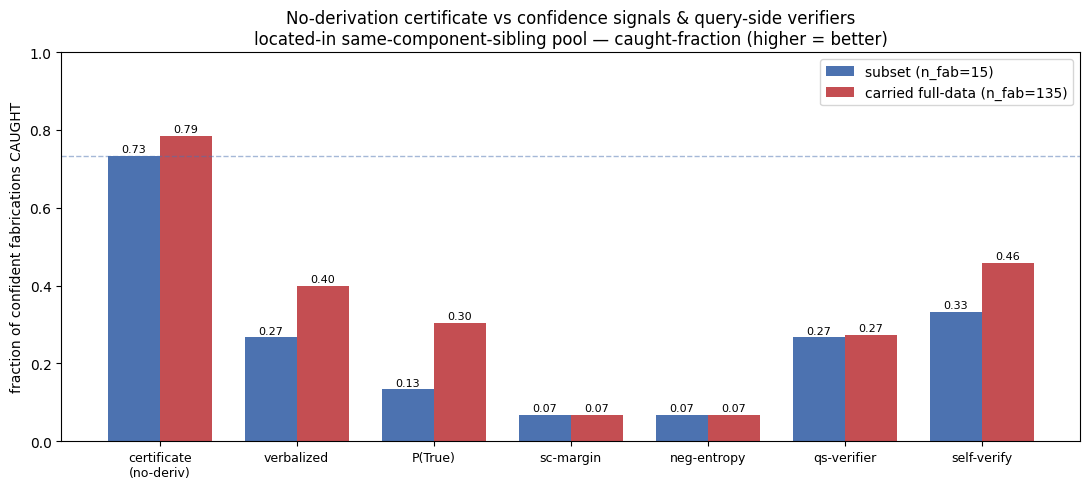

certificate is the top catcher in BOTH the subset and the full-data column.


In [13]:
methods = ["certificate", "ct_verbalized", "ct_ptrue", "ct_sc_margin", "ct_negent",
           "queryside_verifier", "queryside_selfverify"]
labels = ["certificate\n(no-deriv)", "verbalized", "P(True)", "sc-margin", "neg-entropy",
          "qs-verifier", "self-verify"]
subset_vals  = [cm[m]["fraction_caught"] for m in methods]
carried_vals = [ref["caught_fraction_n450"][m] for m in methods]

x = np.arange(len(methods)); w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, subset_vals,  w, label=f"subset (n_fab={len(fab_li)})", color="#4C72B0")
b2 = ax.bar(x + w/2, carried_vals, w, label="carried full-data (n_fab=135)", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("fraction of confident fabrications CAUGHT")
ax.set_title("No-derivation certificate vs confidence signals & query-side verifiers\n"
             "located-in same-component-sibling pool — caught-fraction (higher = better)")
ax.axhline(subset_vals[0], ls="--", lw=1, color="#4C72B0", alpha=.5)
ax.legend(); ax.set_ylim(0, 1.0)
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{b.get_height():.2f}", ha="center", fontsize=8)
plt.tight_layout(); plt.savefig("caught_fraction_demo.png", dpi=110); plt.show()
print("certificate is the top catcher in BOTH the subset and the full-data column.")

## Summary table — located-in (S1) re-analysis: subset vs carried full-data literals

In [14]:
print("=" * 72)
print("LOCATED-IN (S1) RE-ANALYSIS — DEMO SUMMARY")
print("=" * 72)
rows = [
    ("FACT-A sibling (fabrication rate)", f"{factA_sib:.3f}", ref["FACT_A"]["same_component_sibling"]),
    ("FACT-A diffcomponent",             f"{factA_diff:.3f}", ref["FACT_A"]["different_component"]),
    ("caught: certificate",              f"{cm['certificate']['fraction_caught']:.3f}", ref["caught_fraction_n450"]["certificate"]),
    ("caught: self-verify (best q-side)",f"{cm['queryside_selfverify']['fraction_caught']:.3f}", ref["caught_fraction_n450"]["queryside_selfverify"]),
    ("caught: verbalized confidence",    f"{cm['ct_verbalized']['fraction_caught']:.3f}", ref["caught_fraction_n450"]["ct_verbalized"]),
    ("natural conf-wrong: certificate",  f"{li_natcw['certificate']:.3f}", ref["natural_confident_wrong_sibling"]["certificate"]),
    ("natural conf-wrong: verbalized",   f"{li_natcw['ct_verbalized']:.3f}", ref["natural_confident_wrong_sibling"]["ct_verbalized"]),
]
print(f"{'metric':38s} {'subset':>10s} {'carried':>10s}")
for name, sub, car in rows:
    print(f"{name:38s} {sub:>10s} {str(car):>10s}")
print("-" * 72)
print("gold-read ceiling (carried):", ref["gold_read_ceiling"])
print("located-in verdict (carried):", ref["verdict"])
print(f"$0 re-analysis — COST_USD = {COST_USD} | N_LLM_CALLS = {N_LLM_CALLS}")
assert COST_USD == 0.0 and N_LLM_CALLS == 0, "this re-analysis must remain $0"
print("\nDemo complete.")

LOCATED-IN (S1) RE-ANALYSIS — DEMO SUMMARY
metric                                     subset    carried
FACT-A sibling (fabrication rate)           0.250        0.3
FACT-A diffcomponent                        0.100       0.06
caught: certificate                         0.733     0.7852
caught: self-verify (best q-side)           0.333     0.4593
caught: verbalized confidence               0.267        0.4
natural conf-wrong: certificate             0.083     0.0733
natural conf-wrong: verbalized              0.250        0.3
------------------------------------------------------------------------
gold-read ceiling (carried): {'present_coverage': 1.0, 'correct_absent_abstention_rate': 1.0, 'present_selective_accuracy': 1.0}
located-in verdict (carried): EXTRACTION-LIMITED-BOUNDARY
$0 re-analysis — COST_USD = 0.0 | N_LLM_CALLS = 0

Demo complete.
